In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import numpy as np

In [33]:
data = pd.read_csv("../../datasets/BankChurner/BankChurners.csv")
print(f"Data shape: {data.shape}")

Data shape: (10127, 23)


In [34]:
data.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


In [35]:
# drop unncessary cols
data = data.drop(
    columns=[
        "CLIENTNUM",
        "Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1",
        "Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2",
        "Contacts_Count_12_mon",
    ]
)
data.head()

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,4716.0,0,4716.0,2.175,816,28,2.500,0.000


In [36]:
# check for duplicates

print(f"Number of duplicates: {data.duplicated().sum()}")

Number of duplicates: 0


In [37]:
# check for missing values
print(f"Number of missing values: {data.isnull().sum()}")

Number of missing values: Attrition_Flag              0
Customer_Age                0
Gender                      0
Dependent_count             0
Education_Level             0
Marital_Status              0
Income_Category             0
Card_Category               0
Months_on_book              0
Total_Relationship_Count    0
Months_Inactive_12_mon      0
Credit_Limit                0
Total_Revolving_Bal         0
Avg_Open_To_Buy             0
Total_Amt_Chng_Q4_Q1        0
Total_Trans_Amt             0
Total_Trans_Ct              0
Total_Ct_Chng_Q4_Q1         0
Avg_Utilization_Ratio       0
dtype: int64


In [38]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, LabelEncoder
import pandas as pd

# Separate target
le = LabelEncoder()
y = le.fit_transform(data["Attrition_Flag"])
# Feature matrix
X = data.drop("Attrition_Flag", axis=1)

col_trf = ColumnTransformer(
    transformers=[
        (
            "ordinal",
            OrdinalEncoder(),
            [
                "Education_Level",
                "Income_Category",
                "Card_Category",
                "Marital_Status",
                "Gender",
            ],
        ),
    ],
    remainder="passthrough",
)

encoded_X = col_trf.fit_transform(X)

# Convert back to DataFrame
new_data = pd.DataFrame(
    encoded_X,
    columns=col_trf.get_feature_names_out(),
    index=data.index,
)

# Add encoded target back
new_data["Attrition_Flag"] = y

new_data.head()

,ordinal__Education_Level,ordinal__Income_Category,ordinal__Card_Category,ordinal__Marital_Status,ordinal__Gender,remainder__Customer_Age,remainder__Dependent_count,remainder__Months_on_book,remainder__Total_Relationship_Count,remainder__Months_Inactive_12_mon,remainder__Credit_Limit,remainder__Total_Revolving_Bal,remainder__Avg_Open_To_Buy,remainder__Total_Amt_Chng_Q4_Q1,remainder__Total_Trans_Amt,remainder__Total_Trans_Ct,remainder__Total_Ct_Chng_Q4_Q1,remainder__Avg_Utilization_Ratio,Attrition_Flag
0,3.0,2.0,0.0,1.0,1.0,45.0,3.0,39.0,5.0,1.0,12691.0,777.0,11914.0,1.335,1144.0,42.0,1.625,0.061,1
1,2.0,4.0,0.0,2.0,0.0,49.0,5.0,44.0,6.0,1.0,8256.0,864.0,7392.0,1.541,1291.0,33.0,3.714,0.105,1
2,2.0,3.0,0.0,1.0,1.0,51.0,3.0,36.0,4.0,1.0,3418.0,0.0,3418.0,2.594,1887.0,20.0,2.333,0.000,1
3,3.0,4.0,0.0,3.0,0.0,40.0,4.0,34.0,3.0,4.0,3313.0,2517.0,796.0,1.405,1171.0,20.0,2.333,0.760,1
4,5.0,2.0,0.0,1.0,1.0,40.0,3.0,21.0,5.0,1.0,4716.0,0.0,4716.0,2.175,816.0,28.0,2.500,0.000,1


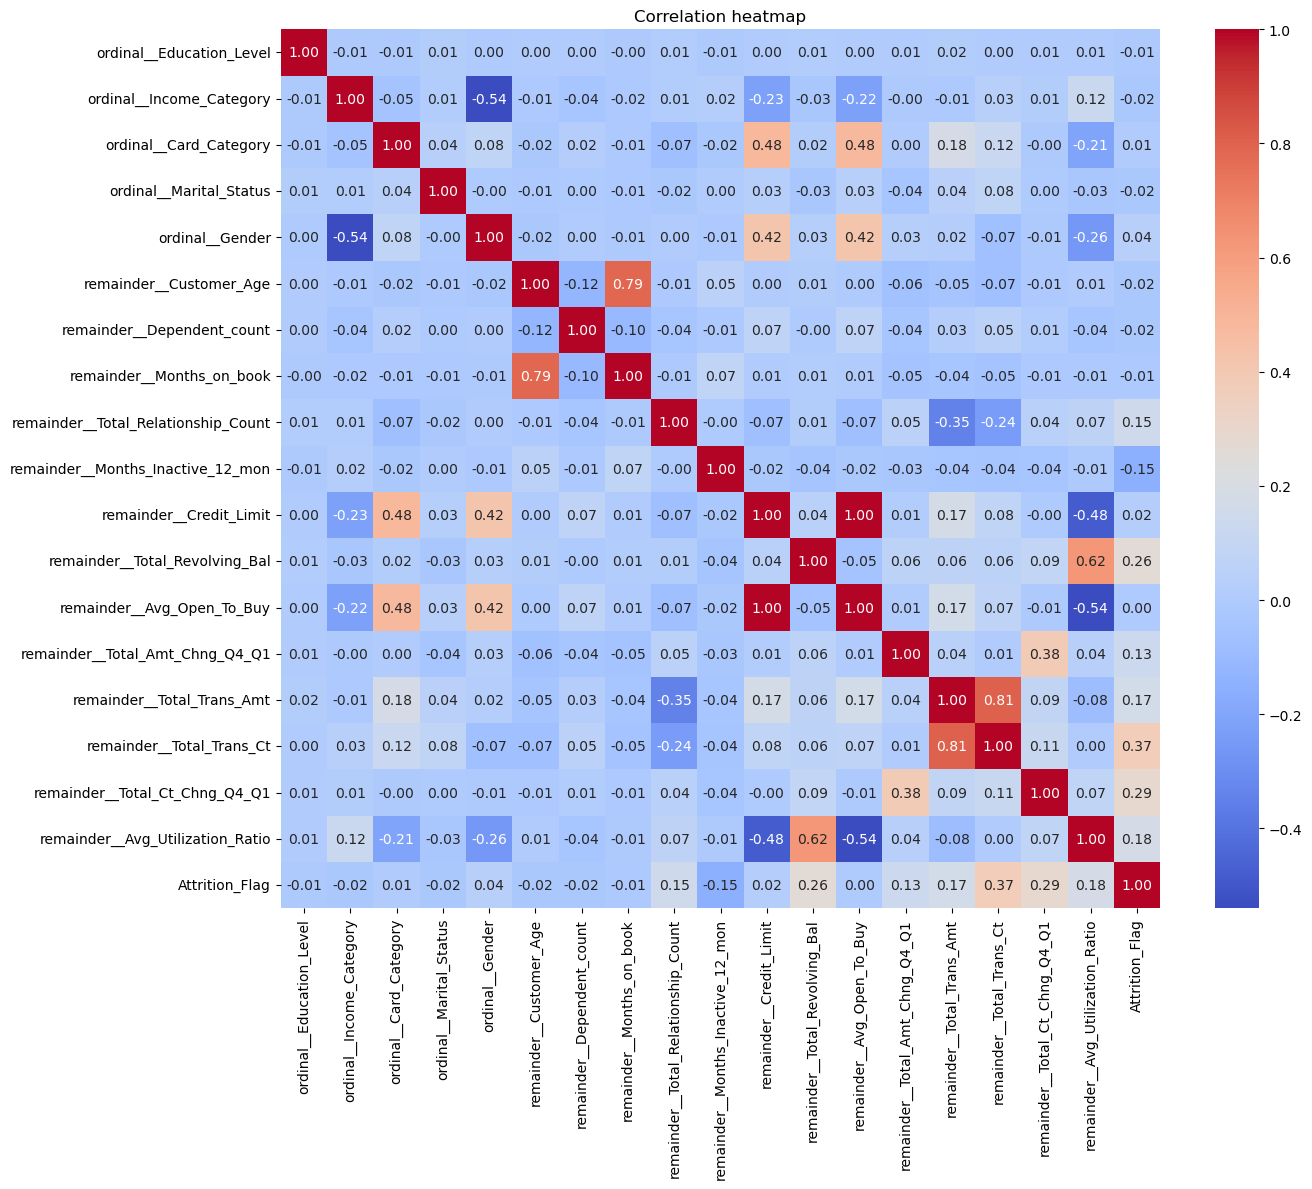

In [41]:
plt.figure(figsize=(14, 12))
sb.heatmap(new_data.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation heatmap")
plt.tight_layout()
plt.show()